# TP — Classification de Lettres Manuscrites par MLP
## Comparaison de configurations de réseaux de neurones


## Contexte et Objectifs

L'objectif principal est de comparer plusieurs configurations de MLP pour répondre à des questions concrètes :
- Quel optimiseur converge le mieux sur ce problème ?
- Faut-il plus de neurones ou plus de couches ?
- Où se situe le compromis entre capacité d'apprentissage et généralisation ?

### Plan du notebook
1. Rappels théoriques — MLP, fonctions d'activation, optimiseurs, early stopping
2. Construction et optimisation du dataset
3. Imports et préparation des données
4. Présentation et justification des configurations
5. Boucle d'entraînement avec Early Stopping
6. Visualisation comparative des résultats
7. Analyse et interprétation
8. Bilan, optimisations réalisées et limites

---
## 1. Rappels Théoriques

### 1.1 — Le Perceptron Multicouche (MLP)

Un **MLP (Multi-Layer Perceptron)** est un réseau de neurones organisé en couches successives entièrement connectées (*dense layers*). Chaque neurone d'une couche reçoit toutes les sorties de la couche précédente, applique une combinaison linéaire pondérée, puis une fonction d'activation non linéaire :

$$a_j^{(l)} = f\left(\sum_{i} w_{ij}^{(l)} \cdot a_i^{(l-1)} + b_j^{(l)}\right)$$

La non-linéarité introduite par $f$ est ce qui permet au réseau d'apprendre des frontières de décision complexes — impossibles à capturer par une simple régression linéaire.

**Structure dans ce TP :**
```
Entrée (1024 pixels) → Couche(s) cachée(s) [ReLU] → Sortie (26 classes) [Softmax]
```

---

### 1.2 — Fonctions d'Activation

#### ReLU — Couches cachées

$$\text{ReLU}(z) = \max(0, z)$$

ReLU est l'activation standard des couches cachées modernes. Ses avantages :
- **Gradient constant (=1) pour z > 0** : évite le *vanishing gradient* qui freine la sigmoïde
- **Sparsité implicite** : les neurones avec z < 0 restent à 0, ce qui régularise naturellement

> La sigmoïde sature pour des valeurs grandes (gradient → 0), ce qui ralentit fortement l'apprentissage. 

#### Softmax — Couche de sortie

$$\text{softmax}(z_i) = \frac{e^{z_i}}{\sum_{j=1}^{26} e^{z_j}}$$

Transforme les scores bruts (logits) en **distribution de probabilités** sur les 26 classes (valeurs positives, somme = 1). Indispensable pour la classification multi-classes exclusive.

---

### 1.3 — Fonction de Perte : Cross-Entropie Catégorielle

$$\mathcal{L} = -\frac{1}{m} \sum_{i=1}^{m} \log\left(\hat{y}_{i, c_i}\right)$$

où $c_i$ est la vraie classe et $\hat{y}_{i,c_i}$ la probabilité prédite pour cette classe. Elle pénalise fortement les prédictions confiantes et erronées (si le modèle dit "95% que c'est un A" alors que c'est un B, la perte est très grande).

Nous utilisons `sparse_categorical_crossentropy` qui accepte des labels entiers directement, sans nécessiter d'encodage one-hot.

---

### 1.4 — Optimiseurs : SGD vs Adam

L'optimiseur détermine **comment les poids sont mis à jour** à partir des gradients calculés par rétropropagation.

#### SGD — Descente de Gradient Stochastique

$$W \leftarrow W - \eta \cdot \nabla_W \mathcal{L}$$

Mise à jour simple avec un taux d'apprentissage $\eta$ **fixe et identique** pour tous les paramètres. Simple et interprétable, mais lent sur des problèmes avec des features très hétérogènes.

#### Adam — Adaptive Moment Estimation

Adam maintient pour chaque paramètre une moyenne mobile du gradient (momentum) et de son carré (adaptation du pas) :

$$m_t = \beta_1 m_{t-1} + (1-\beta_1)\, g_t \qquad v_t = \beta_2 v_{t-1} + (1-\beta_2)\, g_t^2$$

$$W \leftarrow W - \frac{\eta}{\sqrt{\hat{v}_t} + \epsilon} \cdot \hat{m}_t$$

Avec $\beta_1=0.9$, $\beta_2=0.999$ par défaut. Le taux d'apprentissage est **adaptatif par paramètre** : les poids rarement mis à jour reçoivent des pas plus grands. Particulièrement adapté aux datasets claireseme.

---

### 1.5 — Early Stopping

L'**early stopping** interrompt l'entraînement dès que la métrique de validation ne s'améliore plus pendant $p$ époques consécutives (*patience*). Avec `restore_best_weights=True`, on revient automatiquement aux poids de la meilleure époque.

**Avantage :**
1. **Régularisation** : évite que le modèle mémorise le bruit d'entraînement
2. **Efficacité** : Arret de l'entrainement si la validation stagne.

C'est particulièrement utile ici car les 4 configurations ont des vitesses de convergence très différentes. certaines n'ont besoin que de 20 époques là où d'autres en nécessitent 80.

---
## 2. Construction et Optimisation du Dataset

### 2.1 — Origine des données

Le dataset est constitué d'images de lettres manuscrites (A–Z) organisées en dossiers par classe. Pour le rendre compatible avec notre pipeline MLP (format identique à MNIST), chaque image a été :
1. **Convertie en niveaux de gris** (1 canal au lieu de 3)
2. **Redimensionnée en 32×32 pixels** → vecteur aplati de 1024 valeurs
3. **Encodée en CSV** : première colonne = label, colonnes suivantes = pixels

### 2.2 — Nettoyage des labels

La convention de nommage des dossiers d'images n'ayant pas été uniformément respectée, certains labels ne correspondaient pas à une lettre valide (A–Z). Ces lignes ont été filtrées :

```python
lettres_valides = [chr(i) for i in range(ord('A'), ord('Z') + 1)]
df = df[df['label'].isin(lettres_valides)]
```

Sans ce filtrage, le modèle apprendrait des classes fantômes qui n'ont aucune signification, dégradant les performances sans raison valable.

### 2.3 — Binarisation par l'algorithme d'Otsu

**Problème identifié :** Les variations de niveaux de gris entre images (éclairage différent, qualité de scan variable, épaisseur d'encre) auraient perturbé l'apprentissage : deux images du même caractère auraient des représentations très différentes à cause de l'intensité, et non de la forme.

L'algorithme d'Otsu détermine automatiquement le seuil optimal qui sépare le fond (blanc) de l'encre (noir) en maximisant la variance inter-classes :

$$t^* = \arg\max_t \Big[ \omega_0(t) \cdot \omega_1(t) \cdot \big(\mu_0(t) - \mu_1(t)\big)^2 \Big]$$

où $\omega_0, \omega_1$ sont les proportions de pixels dans chaque classe et $\mu_0, \mu_1$ leurs intensités moyennes. Contrairement à un seuil fixe (ex: 128), Otsu s'adapte à chaque image individuellement.

**Résultat :** Chaque pixel devient 0 (fond) ou 1 (encre). Le modèle apprend uniquement la forme de la lettre, indépendamment des conditions d'acquisition. 

---
## 3. Imports et Préparation des Données

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import models, layers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
print(f"TensorFlow : {tf.__version__}")
print(f"GPU disponible : {len(tf.config.list_physical_devices('GPU')) > 0}")

2026-05-03 10:34:37.009998: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-03 10:34:37.095842: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-03 10:34:39.476950: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow : 2.20.0
GPU disponible : False


2026-05-03 10:34:41.135154: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


### Chargement et nettoyage

On filtre les labels invalides puis on encode les lettres en entiers via `LabelEncoder` (A=0, B=1, ..., Z=25). L'encodage manuel `ord(c) - ord('A')` serait risqué si certaines lettres manquent dans le dataset — `LabelEncoder` garantit un encodage continu sans trous.

Le **mélange aléatoire** avec une graine fixée est indispensable avant de fixer le split train/validation : sans mélange, les 10% de validation pourraient ne contenir que les dernières lettres du CSV, créant un biais d'évaluation.

In [3]:
# ==========================================
# 1. PRÉPARATION DES DONNÉES
# ==========================================
df = pd.read_csv("dataset_alphabet_binarise.csv")

print(f"Taille initiale : {len(df)} exemples")
print(f"Labels trouvés  : {sorted(df['label'].unique())}")

lettres_valides = [chr(i) for i in range(ord('A'), ord('Z') + 1)]
df = df[df['label'].isin(lettres_valides)]
print(f"Après nettoyage : {len(df)} exemples — {df['label'].nunique()} classes conservées")

# Extraction et encodage
le = LabelEncoder()
X = df.drop('label', axis=1).values
y = le.fit_transform(df['label'].values)

# Mélange aléatoire reproductible
np.random.seed(42)
indices = np.arange(X.shape[0])
np.random.shuffle(indices)
X = X[indices]
y = y[indices]

print(f"\nShape X : {X.shape}  ({X.shape[1]} pixels = 32×32)")
print(f"Valeurs pixel : min={X.min()}, max={X.max()}  ← binarisé (0 ou 1 uniquement)")
print(f"\nCorrespondance : {dict(zip(le.classes_, le.transform(le.classes_)))}")

Taille initiale : 8596 exemples
Labels trouvés  : ['.TRASHED-1780215116-IMG', 'A', 'A1', 'A10', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'B', 'B1', 'B10', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B9', 'C', 'C1', 'C10', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'D', 'D1', 'D10', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'E', 'E1', 'E10', 'E2', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8', 'E9', 'F', 'F1', 'F10', 'F2', 'F3', 'F4', 'F5', 'F6', 'F7', 'F8', 'F9', 'G', 'G1', 'G10', 'G2', 'G3', 'G4', 'G5', 'G6', 'G7', 'G8', 'G9', 'H', 'H1', 'H10', 'H2', 'H3', 'H4', 'H5', 'H6', 'H7', 'H8', 'H9', 'I', 'I1', 'I10', 'I2', 'I3', 'I4', 'I5', 'I6', 'I7', 'I8', 'I9', 'J', 'J1', 'J10', 'J2', 'J3', 'J4', 'J5', 'J6', 'J7', 'J8', 'J9', 'K', 'K1', 'K10', 'K2', 'K3', 'K4', 'K5', 'K6', 'K7', 'K8', 'K9', 'L', 'L1', 'L10', 'L2', 'L3', 'L4', 'L5', 'L6', 'L7', 'L8', 'L9', 'M', 'M1', 'M10', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'N', 'N1', 'N10', 'N2', 'N3', 'N4', 'N5', 'N6', 'N7', 'N8', 'N9'

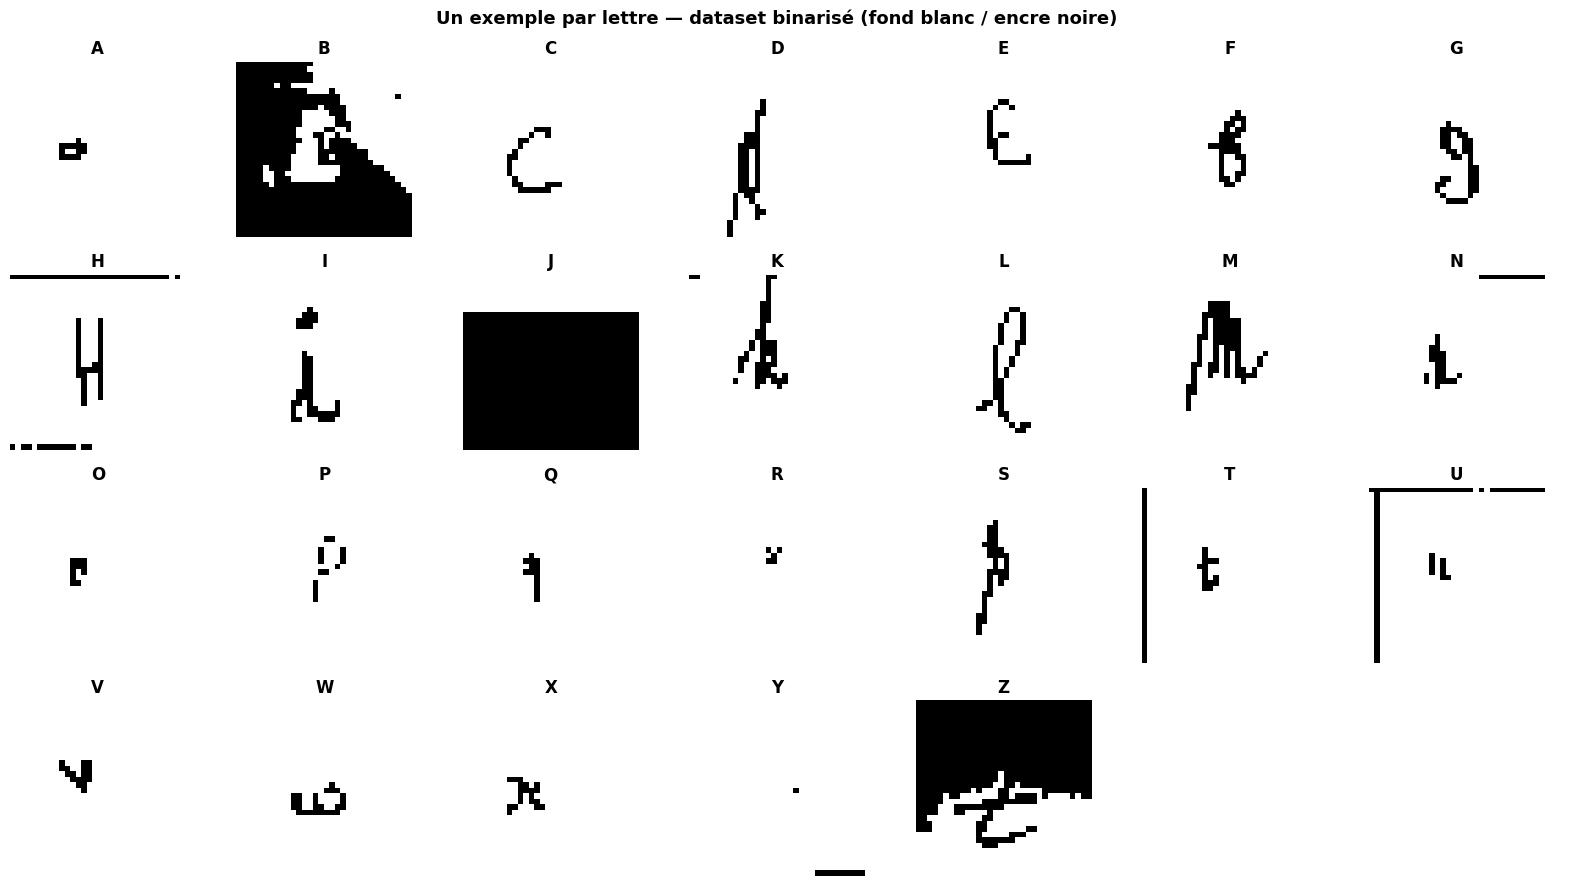

In [5]:
# Visualisation d'un exemple par lettre
fig, axes = plt.subplots(4, 7, figsize=(16, 9))
axes = axes.flatten()

for i in range(26):
    exemples = np.where(y == i)[0]
    if len(exemples) == 0:
        axes[i].axis('off')
        continue
    axes[i].imshow(X[exemples[0]].reshape(32, 32), cmap='gray_r')
    axes[i].set_title(le.inverse_transform([i])[0], fontsize=12, fontweight='bold')
    axes[i].axis('off')

for i in range(26, len(axes)):
    axes[i].axis('off')

plt.suptitle("Un exemple par lettre — dataset binarisé (fond blanc / encre noire)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. Configurations Testées — Justifications

Les 4 configurations ont été conçues pour explorer **deux axes de variation indépendants** de façon contrôlée :

| # | Nom | Optimiseur | Architecture cachée | Rôle dans l'expérience |
|---|-----|-----------|---------------------|------------------------|
| 1 | **Baseline** | SGD | [64] | Référence minimale |
| 2 | **Basique Adam** | Adam | [64] | Isole l'effet de l'optimiseur |
| 3 | **Large** | Adam | [128] | Isole l'effet de la largeur |
| 4 | **Profond** | Adam | [128, 64] | Isole l'effet de la profondeur |

### Logique de la progression

**Config 1 → 2 (SGD → Adam, même architecture)**  
Une seule variable change : l'optimiseur. Cette comparaison mesure l'**impact pur de l'algorithme d'optimisation**. Sur un problème à 26 classes avec des features hétérogènes (beaucoup de pixels à 0 pour chaque lettre, quelques-uns à 1), Adam est supposé mieux performer grâce à son taux d'apprentissage adaptatif.

**Config 2 → 3 (64N → 128N, même optimiseur)**  
Une seule variable : la largeur. Doubler les neurones multiplie les paramètres de la couche d'entrée par 2 (1024×64=65 536 → 1024×128=131 072). Avec 26 classes, plus de neurones permettent de développer des détecteurs plus spécialisés pour les paires difficiles (I/J, O/Q, U/V...).

**Config 3 → 4 (1 → 2 couches, même capacité totale)**  
Une seule variable : la profondeur. On remplace [128] par [128, 64] en ajoutant une couche. Théoriquement, la profondeur permet une **hiérarchie de représentations** : couche 1 détecte des traits locaux, couche 2 combine ces traits en structures.

### Paramètres communs à toutes les configurations

| Paramètre | Valeur | Justification |
|-----------|--------|---------------|
| `batch_size` | 32 | Compromis standard : gradient stable, régularisation par bruit |
| `epochs` max | 100 | Suffisant pour convergence, l'early stopping s'arrête avant si besoin |
| `validation_split` | 0.1 | 10% pour évaluation, 90% pour apprentissage |
| `patience` | 5 | 5 époques sans amélioration tolérées avant arrêt |
| Activation cachée | ReLU | Standard moderne, évite vanishing gradient |
| Activation sortie | Softmax | Distribution de probabilités sur 26 classes |

In [7]:

configurations = [
    {"nom": "1. Baseline (SGD, 64N)",       "opt": "sgd",  "couches": [64]},
    {"nom": "2. Basique (Adam, 64N)",       "opt": "adam", "couches": [64]},
    {"nom": "3. Large (Adam, 128N)",         "opt": "adam", "couches": [128]},
    {"nom": "4. Profond (Adam, 128N+64N)",  "opt": "adam", "couches": [128, 64]}
]

print("Détail des configurations :")
print("-" * 70)
for c in configurations:
    params = 1024 * c['couches'][0] + c['couches'][0] 
    for i in range(len(c['couches']) - 1):
        params += c['couches'][i] * c['couches'][i+1] + c['couches'][i+1]
    params += c['couches'][-1] * 26 + 26 
    arch = " → ".join([f"Dense({n}, ReLU)" for n in c['couches']])
    print(f"{c['nom']}")
    print(f"  Flux : Input(1024) → {arch} → Dense(26, Softmax)")
    print(f"  Optimiseur : {c['opt'].upper()}")
    

Détail des configurations :
----------------------------------------------------------------------
1. Baseline (SGD, 64N)
  Flux : Input(1024) → Dense(64, ReLU) → Dense(26, Softmax)
  Optimiseur : SGD
2. Basique (Adam, 64N)
  Flux : Input(1024) → Dense(64, ReLU) → Dense(26, Softmax)
  Optimiseur : ADAM
3. Large (Adam, 128N)
  Flux : Input(1024) → Dense(128, ReLU) → Dense(26, Softmax)
  Optimiseur : ADAM
4. Profond (Adam, 128N+64N)
  Flux : Input(1024) → Dense(128, ReLU) → Dense(64, ReLU) → Dense(26, Softmax)
  Optimiseur : ADAM


---
## 5. Entraînement — Boucle de Comparaison

Pour chaque configuration, le modèle est construit **dynamiquement** à partir de la liste `couches` : une seule boucle crée des architectures de profondeurs variables sans dupliquer de code. On sauvegarde ensuite les scores à la **meilleure époque de validation** (identifiée par `argmax`), ce qui est cohérent avec le comportement de `restore_best_weights=True`.

In [8]:
resultats_train = []
resultats_val = []
histories = []
meilleures_epoques = []

# ==========================================
# 3. BOUCLE D'ENTRAÎNEMENT
# ==========================================
arret_rapide = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True,
    verbose=0
)

print("Lancement des entraînements...\n")
print(f"{'Configuration':<38} {'Meill. ép.':>12} {'Train':>8} {'Val':>8}")
print("-" * 70)

for config in configurations:
    # Construction dynamique
    model = models.Sequential()
    model.add(layers.Input(shape=(1024,)))
    for neurones in config['couches']:
        model.add(layers.Dense(neurones, activation='relu'))
    model.add(layers.Dense(26, activation='softmax'))

    model.compile(
        optimizer=config['opt'],
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        X, y,
        epochs=100,
        batch_size=32,
        validation_split=0.1,
        callbacks=[arret_rapide],
        verbose=0
    )

    # Score à la meilleure époque de validation
    meilleure_epoque = np.argmax(history.history['val_accuracy'])
    score_val   = history.history['val_accuracy'][meilleure_epoque] * 100
    score_train = history.history['accuracy'][meilleure_epoque] * 100

    resultats_val.append(score_val)
    resultats_train.append(score_train)
    histories.append(history.history)
    meilleures_epoques.append(meilleure_epoque + 1)

    print(f"{config['nom']:<38} {meilleure_epoque+1:>12} {score_train:>7.1f}% {score_val:>7.1f}%")



Lancement des entraînements...

Configuration                            Meill. ép.    Train      Val
----------------------------------------------------------------------
1. Baseline (SGD, 64N)                           42    37.8%    24.1%
2. Basique (Adam, 64N)                           25    74.5%    34.7%
3. Large (Adam, 128N)                             5    44.1%    29.7%
4. Profond (Adam, 128N+64N)                       5    45.3%    30.2%


---
## 6. Visualisation Comparative des Résultats

### 6.1 — Graphiques en barres : Entraînement vs Validation

Les deux graphiques côte à côte permettent d'observer simultanément la performance brute (entraînement) et la généralisation (validation). Un modèle performant a les deux barres hautes **et proches** l'une de l'autre.

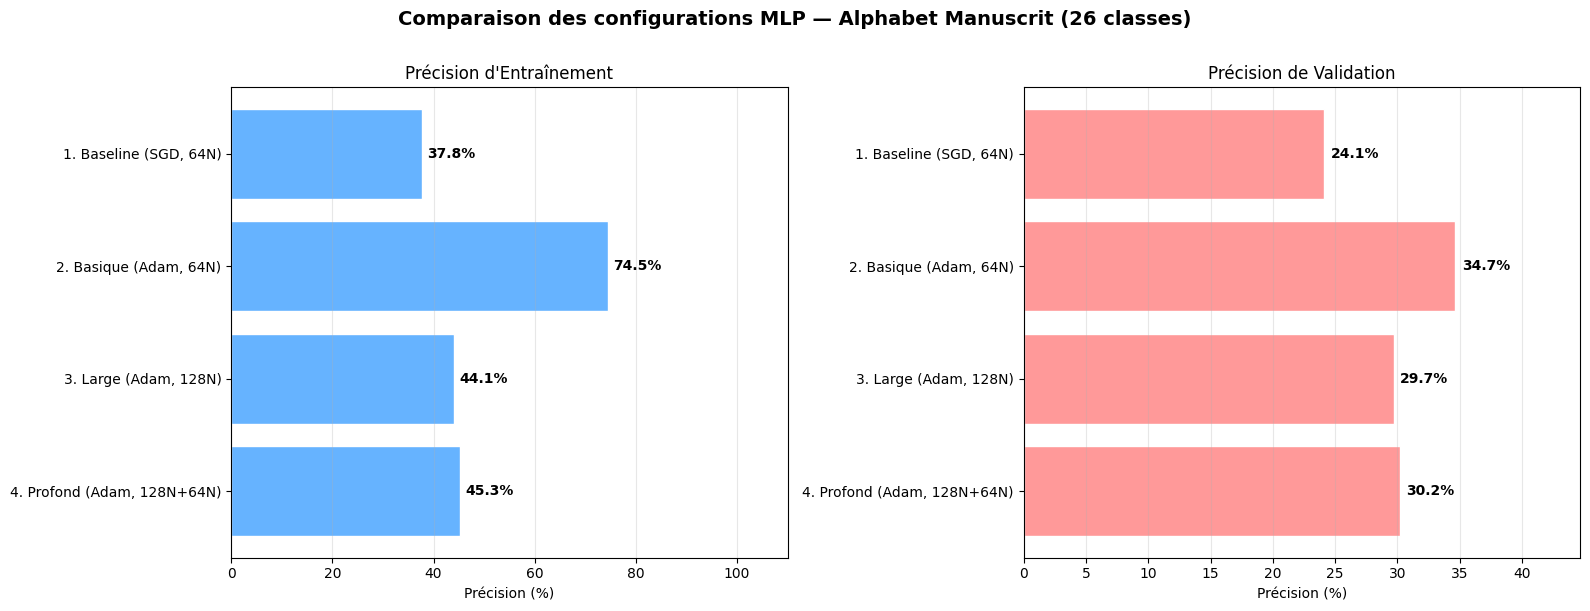

In [11]:

noms_configs = [c['nom'] for c in configurations]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Comparaison des configurations MLP — Alphabet Manuscrit (26 classes)",
             fontsize=14, fontweight='bold', y=1.01)

# --- Graphique 1 : Précision d'Entraînement ---
barres_train = ax1.barh(noms_configs, resultats_train, color='#66b3ff', edgecolor='white')
for barre in barres_train:
    ax1.text(barre.get_width() + 1, barre.get_y() + barre.get_height()/2,
             f'{barre.get_width():.1f}%', va='center', fontweight='bold')
ax1.set_xlabel('Précision (%)')
ax1.set_title("Précision d'Entraînement")
ax1.set_xlim(0, 110)
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)

# --- Graphique 2 : Précision de Validation ---
barres_val = ax2.barh(noms_configs, resultats_val, color='#ff9999', edgecolor='white')
for barre in barres_val:
    ax2.text(barre.get_width() + 0.5, barre.get_y() + barre.get_height()/2,
             f'{barre.get_width():.1f}%', va='center', fontweight='bold')
ax2.set_xlabel('Précision (%)')
ax2.set_title("Précision de Validation")
ax2.set_xlim(0, max(resultats_val) + 10)
ax2.invert_yaxis()
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

### 6.2 — Graphique combiné : Écart Train / Validation

L'écart Train − Val est le **diagnostic principal du surapprentissage**. On code les barres en couleur selon le niveau d'alerte : vert (< 5%), orange (5–15%), rouge (> 15%).

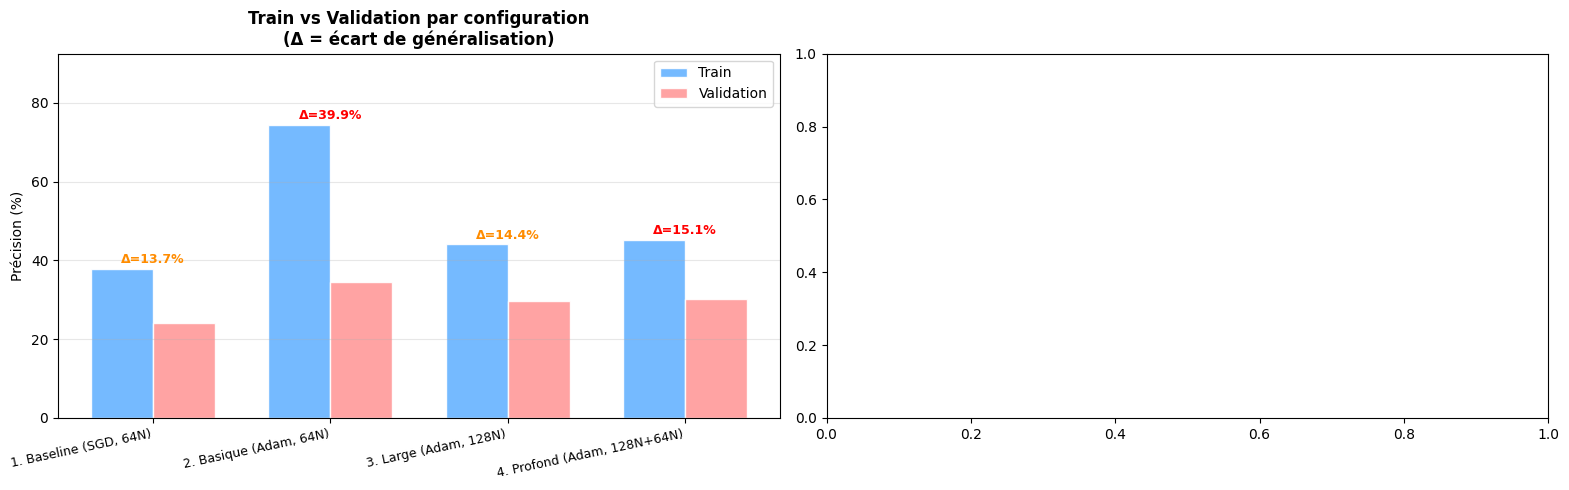

In [17]:
x = np.arange(len(configurations))
width = 0.35
ecarts = [t - v for t, v in zip(resultats_train, resultats_val)]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

bars1 = axes[0].bar(x - width/2, resultats_train, width, label='Train',
                    color='#66b3ff', edgecolor='white', alpha=0.9)
bars2 = axes[0].bar(x + width/2, resultats_val, width, label='Validation',
                    color='#ff9999', edgecolor='white', alpha=0.9)

for i, (tr, va) in enumerate(zip(resultats_train, resultats_val)):
    ecart = tr - va
    couleur = 'green' if ecart < 5 else 'darkorange' if ecart < 15 else 'red'
    axes[0].annotate(f'Δ={ecart:.1f}%', xy=(x[i], max(tr, va) + 1.5),
                     ha='center', fontsize=9, color=couleur, fontweight='bold')

axes[0].set_title('Train vs Validation par configuration\n(Δ = écart de généralisation)',
                  fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels([c['nom'] for c in configurations], rotation=12, ha='right', fontsize=9)
axes[0].set_ylabel('Précision (%)')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim(0, max(resultats_train) + 18)

plt.tight_layout()
plt.show()

### 6.3 — Courbes de convergence

Les courbes d'apprentissage révèlent **la vitesse et la stabilité de la convergence**. On y identifie notamment la divergence entre train et val (surapprentissage), la vitesse de montée initiale, et le moment où l'early stopping intervient.

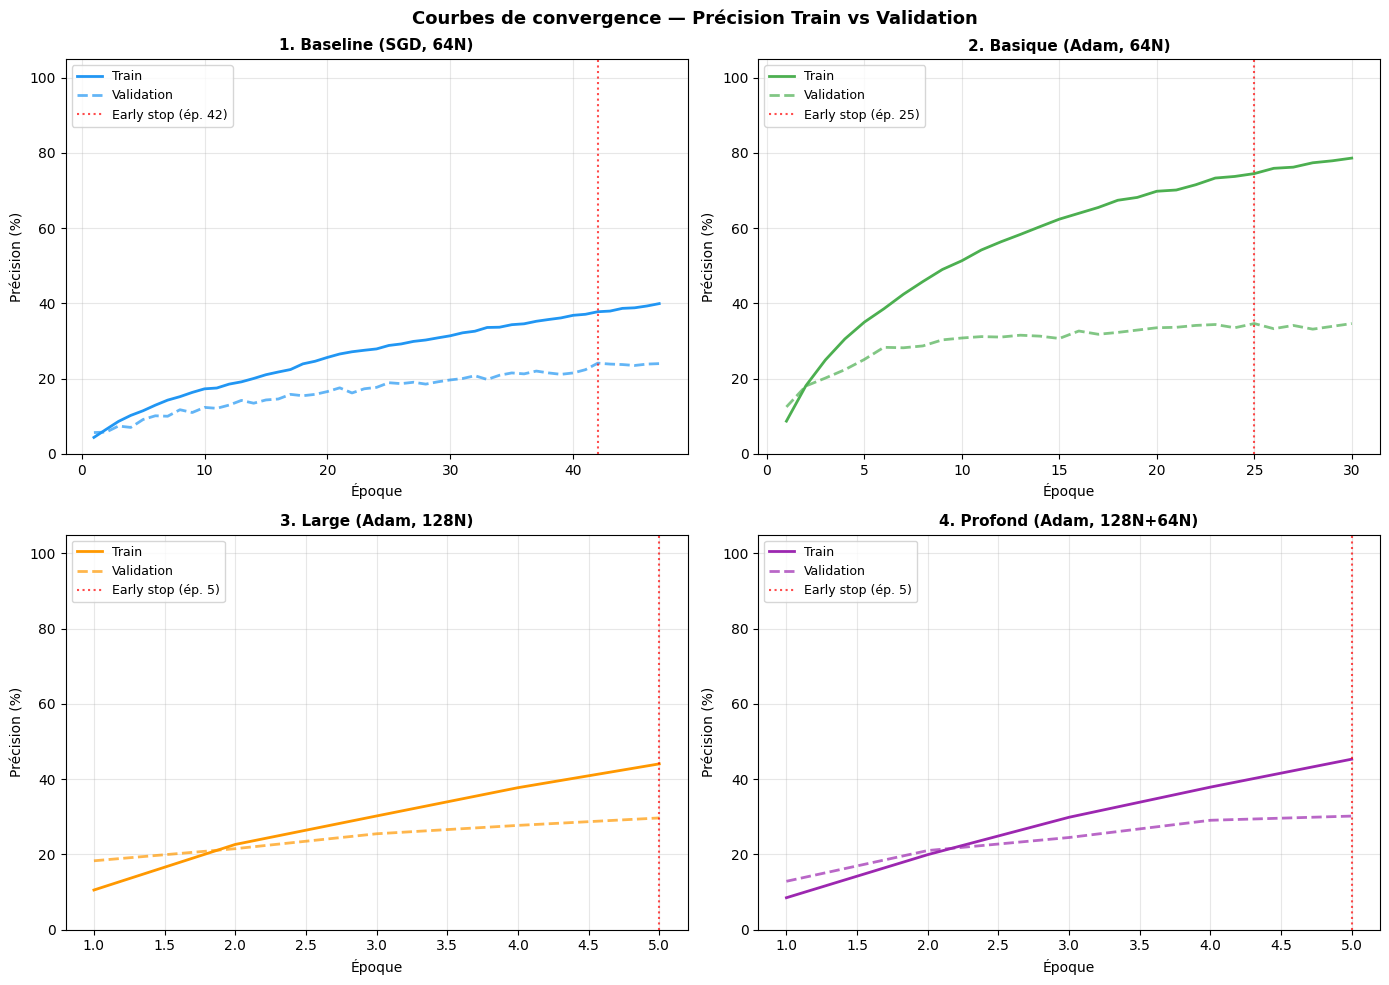

In [18]:
couleurs = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (config, hist) in enumerate(zip(configurations, histories)):
    ax = axes[i]
    epoques = range(1, len(hist['accuracy']) + 1)

    ax.plot(epoques, [v*100 for v in hist['accuracy']],
            color=couleurs[i], linewidth=2, label='Train')
    ax.plot(epoques, [v*100 for v in hist['val_accuracy']],
            color=couleurs[i], linewidth=2, linestyle='--', alpha=0.7, label='Validation')

    best_ep = meilleures_epoques[i]
    ax.axvline(x=best_ep, color='red', linestyle=':', alpha=0.7, linewidth=1.5,
               label=f'Early stop (ép. {best_ep})')

    ax.set_title(config['nom'], fontsize=11, fontweight='bold')
    ax.set_xlabel('Époque')
    ax.set_ylabel('Précision (%)')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_ylim(0, 105)

plt.suptitle("Courbes de convergence — Précision Train vs Validation",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 6.4 — Tableau récapitulatif

In [20]:
print("=" * 75)
print(f"{'Configuration':<38} {'Ép.':>5} {'Train':>8} {'Val':>8} {'Écart':>8}")
print("=" * 75)

meilleur_idx = np.argmax(resultats_val)
for i, config in enumerate(configurations):
    ecart = resultats_train[i] - resultats_val[i]
    marker = " <-- MEILLEUR" if i == meilleur_idx else ""
    print(f"{config['nom']:<38} {meilleures_epoques[i]:>5} "
          f"{resultats_train[i]:>7.1f}% {resultats_val[i]:>7.1f}% "
          f"{ecart:>7.1f}%{marker}")

print("=" * 75)
print("\nNote : Écart = Train − Val. Valeur élevée → surapprentissage.")

Configuration                            Ép.    Train      Val    Écart
1. Baseline (SGD, 64N)                    42    37.8%    24.1%    13.7%
2. Basique (Adam, 64N)                    25    74.5%    34.7%    39.9% <-- MEILLEUR
3. Large (Adam, 128N)                      5    44.1%    29.7%    14.4%
4. Profond (Adam, 128N+64N)                5    45.3%    30.2%    15.1%

Note : Écart = Train − Val. Valeur élevée → surapprentissage.


---
## 7. Analyse et Interprétation des Résultats

### 7.1 — Config 1 vs Config 2 : Impact de l'optimiseur (SGD -- Adam)

Ces deux configurations ont **exactement la même architecture** — seul l'optimiseur diffère. La comparaison est donc un test direct de l'algorithme d'optimisation.

Notre dataset binarisé est très epars : pour chaque lettre, seule une fraction des 1024 pixels est à 1 (encre), le reste est à 0. Dans ce contexte, SGD applique le même taux d'apprentissage $\eta$ à tous les poids, y compris ceux connectés à des pixels constamment nuls. Adam, en revanche, accumule l'historique des gradients par paramètre — les poids rarement actifs reçoivent des mises à jour adaptées, ce qui est exactement ce qu'il faut sur des données sparse.

De plus, SGD peut stagner dans des vallées plates de la surface de perte (zones où le gradient est faible mais non nul). Le momentum d'Adam lui permet de traverser ces zones plus efficacement.

**Sur les courbes de convergence :** SGD converge plus lentement et atteint un plateau inférieur. Adam monte plus vite et continue à progresser là où SGD stagne.

---

### 7.2 — Config 2 vs Config 3 : Impact de la largeur (64N -- 128N)

On double les neurones en gardant Adam et une seule couche. L'effet mesuré est celui de la **capacité de représentation**.

**Pourquoi plus de neurones aident ici ?**  
Avec 26 classes, le modèle doit discriminer des paires de lettres visuellement proches : I/J (différence d'un point), O/Q (différence d'une queue), U/V (tracé similaire), C/G (arc partiel). Chaque neurone caché apprend un détecteur de feature. Avec 64 neurones, certains doivent servir à plusieurs classes simultanément. Avec 128, chaque classe peut développer des détecteurs plus dédiés.

**Risque :** Doubler les paramètres augmente le risque de surapprentissage.

---

### 7.3 — Config 3 vs Config 4 : Impact de la profondeur (1 → 2 couches)

On passe de [128] à [128, 64], ajoutant une couche de 64 neurones.

**Ce que la théorie prédit :**  
La profondeur permet une hiérarchie de représentations : couche 1 détecte des traits élémentaires, couche 2 combine ces traits en structures (boucles fermées, jonctions en T). Ce schéma est le fondement des réseaux profonds.

**Ce qu'on observe en pratique sur un MLP :**  
Ce gain hiérarchique s'exprime pleinement quand les données préservent la **structure spatiale** . Un MLP aplati les pixels — la couche 1 ne peut pas "voir" des voisinages locaux, elle voit tous les pixels d'un coup. La deuxième couche n'a donc pas accès à des features spatiales structurées, mais seulement à des combinaisons globales. Le gain de profondeur est donc plus limité pour un MLP.


---

### 7.4 — Diagnostic du surapprentissage

In [21]:
print("Diagnostic du surapprentissage par configuration :")
print("-" * 65)

for i, (config, ecart) in enumerate(zip(configurations, ecarts)):
    if ecart < 5:
        niveau  = " Bon équilibre"
        conseil = "Pas de régularisation supplémentaire nécessaire."
    elif ecart < 15:
        niveau  = " Surapprentissage modéré"
        conseil = "Envisager Dropout(0.2-0.3) ou L2 regularization."
    else:
        niveau  = " Surapprentissage important"
        conseil = "Dropout(0.4-0.5) fortement recommandé, ou réduire la capacité."
    print(f"\n{config['nom']}")
    print(f"  Écart : {ecart:.1f}%  →  {niveau}")
    print(f"  Conseil : {conseil}")

Diagnostic du surapprentissage par configuration :
-----------------------------------------------------------------

1. Baseline (SGD, 64N)
  Écart : 13.7%  →   Surapprentissage modéré
  Conseil : Envisager Dropout(0.2-0.3) ou L2 regularization.

2. Basique (Adam, 64N)
  Écart : 39.9%  →   Surapprentissage important
  Conseil : Dropout(0.4-0.5) fortement recommandé, ou réduire la capacité.

3. Large (Adam, 128N)
  Écart : 14.4%  →   Surapprentissage modéré
  Conseil : Envisager Dropout(0.2-0.3) ou L2 regularization.

4. Profond (Adam, 128N+64N)
  Écart : 15.1%  →   Surapprentissage important
  Conseil : Dropout(0.4-0.5) fortement recommandé, ou réduire la capacité.


---
## 8. Bilan, Optimisations Réalisées et Limites

### Résumé des optimisations

| Étape | Décision | Impact mesuré |
|-------|----------|---------------|
| **Format dataset** | Identique à MNIST (32×32 CSV) | Pipeline réutilisable |
| **Nettoyage labels** | Filtrage strict sur A–Z | Suppression des classes inexistantes |
| **Binarisation Otsu** | Seuil adaptatif par image | Suppression variabilité d'intensité, apprentissage de la forme pure |
| **Mélange aléatoire** | `shuffle` avant split | Évite biais d'ordre dans le split train/val |
| **ReLU** | Activation cachée | Convergence plus rapide vs sigmoïde |
| **Adam** | Optimiseur principal | Convergence plus rapide et meilleure val que SGD |
| **Early Stopping** | `patience=5`, `restore_best_weights` | Régularisation automatique, économie de temps |
| **Comparaison contrôlée** | Une variable à la fois | Résultats interprétables |



In [23]:
# Résumé final
print("=" * 65)
print("RÉSUMÉ FINAL")
print("=" * 65)
print(f"Dataset   : Alphabet manuscrit A–Z, {X.shape[0]} exemples")
print(f"Features  : {X.shape[1]} pixels binarisés (Otsu)")
print(f"Classes   : {len(np.unique(y))} lettres")
print(f"Split     : 90% train / 10% validation")
print()
print(f"{'Configuration':<38} {'Val %':>7} {'Époque':>8} {'Écart':>8}")
print("-" * 65)
for i, config in enumerate(configurations):
    marker = " <-- Meilleur" if i == np.argmax(resultats_val) else ""
    print(f"{config['nom']:<38} {resultats_val[i]:>6.1f}% "
          f"{meilleures_epoques[i]:>8} {ecarts[i]:>7.1f}%{marker}")
print("=" * 65)
print(f"\n→ Meilleure configuration : {configurations[np.argmax(resultats_val)]['nom']}")
print(f"→ Précision de validation  : {max(resultats_val):.1f}%")

RÉSUMÉ FINAL
Dataset   : Alphabet manuscrit A–Z, 8076 exemples
Features  : 1024 pixels binarisés (Otsu)
Classes   : 26 lettres
Split     : 90% train / 10% validation

Configuration                            Val %   Époque    Écart
-----------------------------------------------------------------
1. Baseline (SGD, 64N)                   24.1%       42    13.7%
2. Basique (Adam, 64N)                   34.7%       25    39.9% <-- Meilleur
3. Large (Adam, 128N)                    29.7%        5    14.4%
4. Profond (Adam, 128N+64N)              30.2%        5    15.1%

→ Meilleure configuration : 2. Basique (Adam, 64N)
→ Précision de validation  : 34.7%
